In [710]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def intial_distance_to_obstacle(df):
    for ind,row in df.iterrows():
        df.at[ind,'intial_distance'] = np.round(row.ts_distance_from_edge[0])

In [711]:
test = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint.h5")
test1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint1.h5")
joint = pd.concat([test,test1])
intial_distance_to_obstacle(joint)
distance_at_head_turn(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

In [7]:
plt.rcParams.update({'font.size': 24,
                     'font.weight': 'bold',
                     'axes.linewidth':    1,
                     'xtick.major.size':  3,
                     'xtick.major.width': 1,
                     'ytick.major.size':  3,
                     'ytick.major.width': 1,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'pdf.fonttype':      42,
                     'xtick.labelsize':   24,
                     'ytick.labelsize':   24,
                     'figure.facecolor': 'white'
                    })

In [248]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
data.sample(10)[['task','angle_at_head_turn','angle_after_head_turn','angle_before_head_turn','angle_headturn_delta','distance_at_head_turn','distance_after_head_turn','distance_before_head_turn','turn_to_obstacle']]

,task,angle_at_head_turn,angle_after_head_turn,angle_before_head_turn,angle_headturn_delta,distance_at_head_turn,distance_after_head_turn,distance_before_head_turn,turn_to_obstacle
10712,oadark,63.643094,12.206835,85.564376,73.357541,19.558580,5.983706,22.005585,towards
13128,oadark,60.624884,12.670188,79.962734,67.292547,14.621623,2.072125,19.120342,towards
3927,oa,42.271684,11.032128,65.046964,54.014836,12.999587,8.799285,21.271821,towards
4778,oa,41.867421,2.134893,13.453246,11.318354,3.326359,2.589346,6.242919,towards
6571,oa,82.850782,110.992489,65.383934,-45.608554,1.850101,2.708253,21.138779,towards
9010,oadark,69.000463,42.189317,87.037407,44.848090,17.595101,7.599101,21.107034,towards
2291,oa,74.288837,5.375545,100.570732,95.195186,25.136245,3.284730,26.589470,towards
2349,oa,49.762558,18.153183,48.758750,30.605567,12.982438,11.607161,16.643226,towards
1696,oa,53.303328,9.204161,63.263241,54.059080,2.627795,3.191811,6.897385,towards
13041,oadark,31.129567,39.505045,23.898519,-15.606526,4.762541,3.734212,5.860177,towards


In [226]:
long_nostart.sample(10)[['distance_at_head_turn','distance_after_head_turn']]

,distance_at_head_turn,distance_after_head_turn
6829,17.695925,11.252513
2289,25.092895,20.928351
402,2.865057,3.562255
5377,8.095849,1.612058
181,21.635492,8.988182
3027,18.877468,9.110058
218,25.973069,27.723859
10062,22.181115,5.105581
9926,2.480688,3.028339
10838,23.100686,12.806023


In [704]:
peaks[prop['peak_heights']]

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
head_turn_velocity

Text(0.5, 0.98, 'long towards')

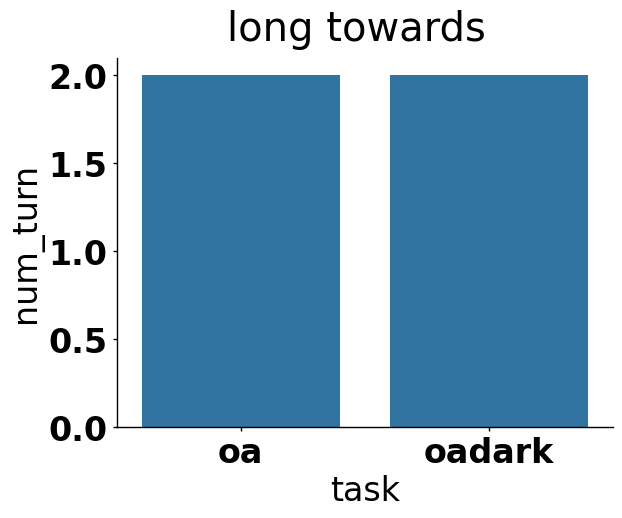

In [718]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
#data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
sns.barplot(data = data, x = 'task', y = 'num_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

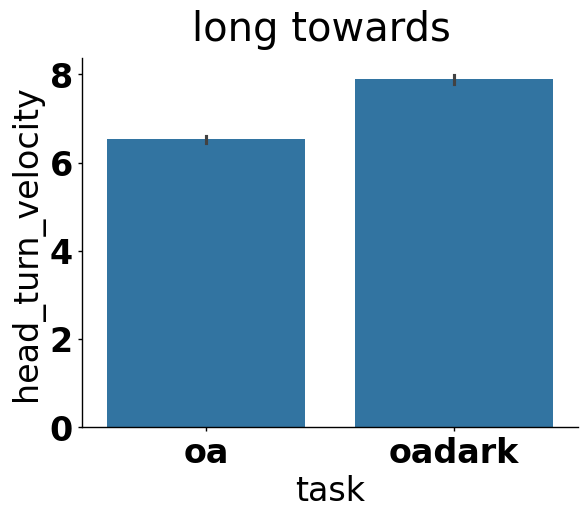

In [716]:
data = joint
data = data[data.turn_to_obstacle == 'towards']
#data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
sns.barplot(data = data, x = 'task', y = 'head_turn_velocity',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

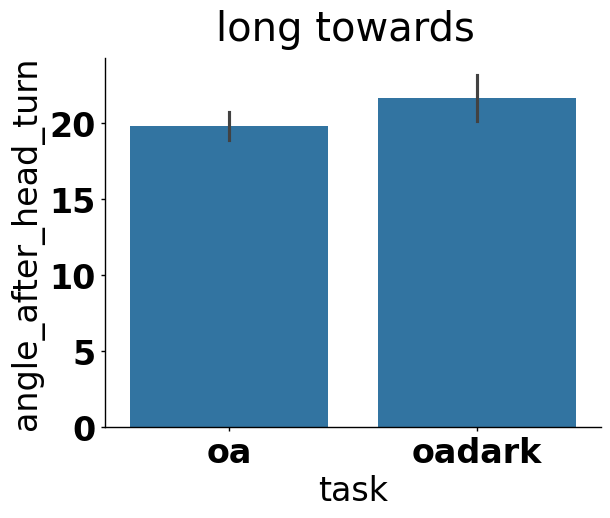

In [721]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'angle_after_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

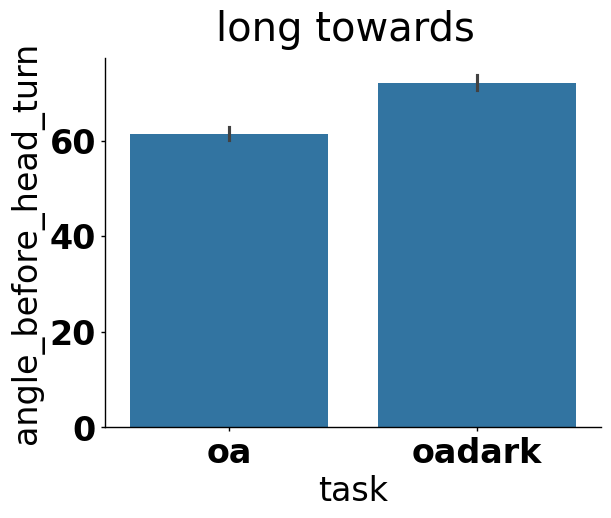

In [720]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'angle_before_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

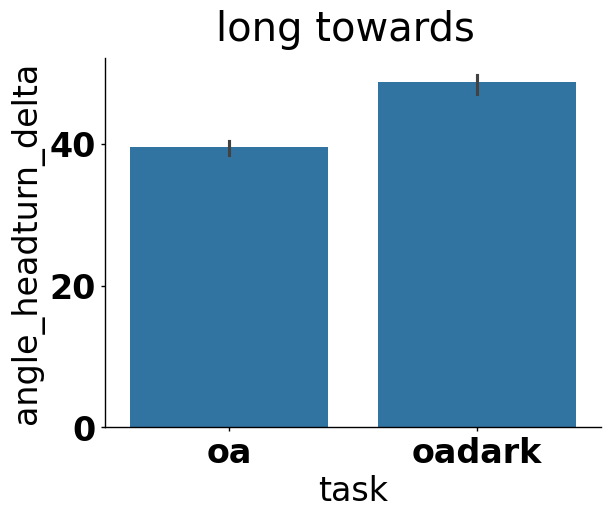

In [719]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'angle_headturn_delta',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

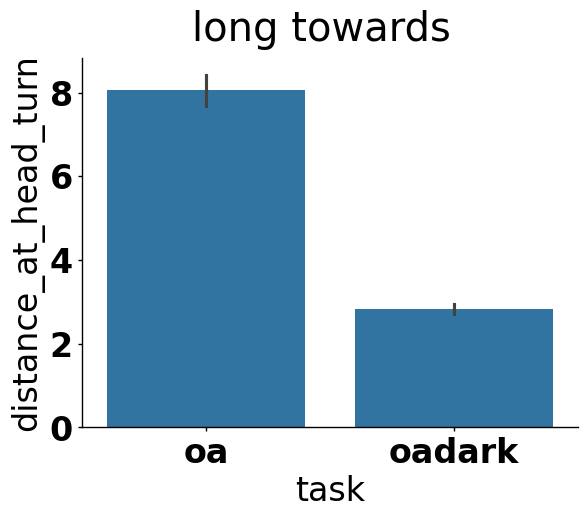

In [657]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
data['angle_headturn_delta']= data.angle_before_head_turn-data.angle_after_head_turn
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'distance_at_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

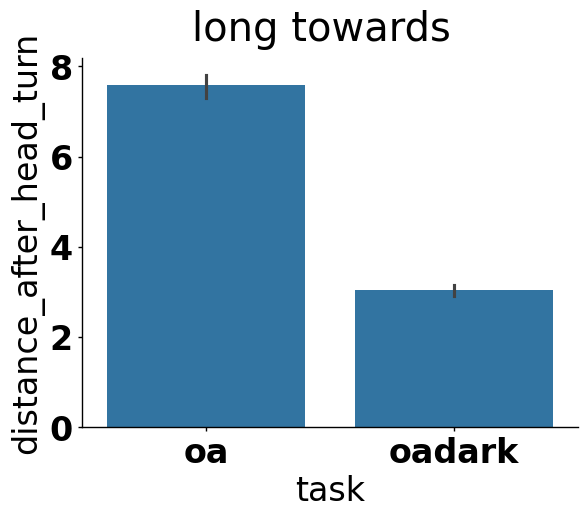

In [658]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'distance_after_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

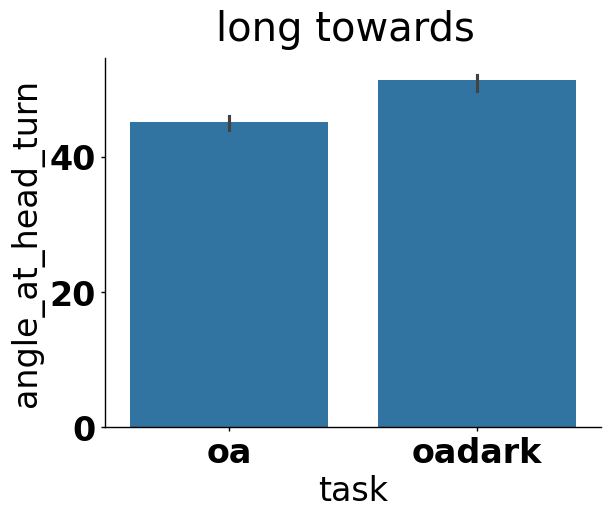

In [659]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'angle_at_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

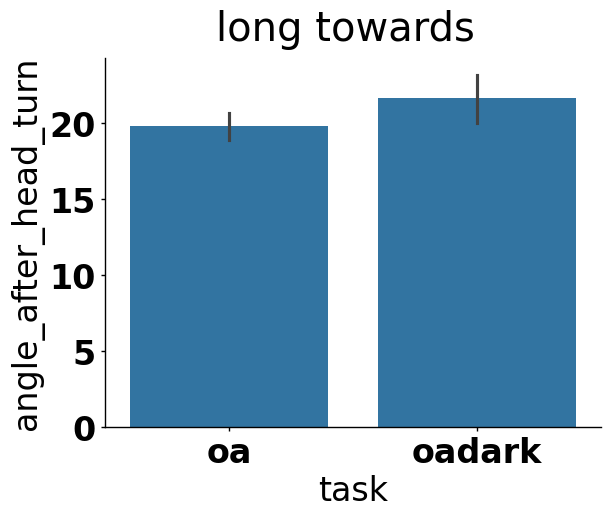

In [660]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'angle_after_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

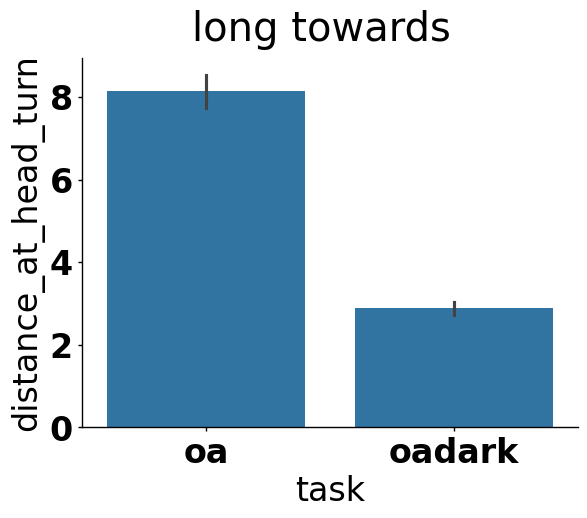

In [579]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'distance_at_head_turn',estimator='median')
plt.suptitle('long towards')

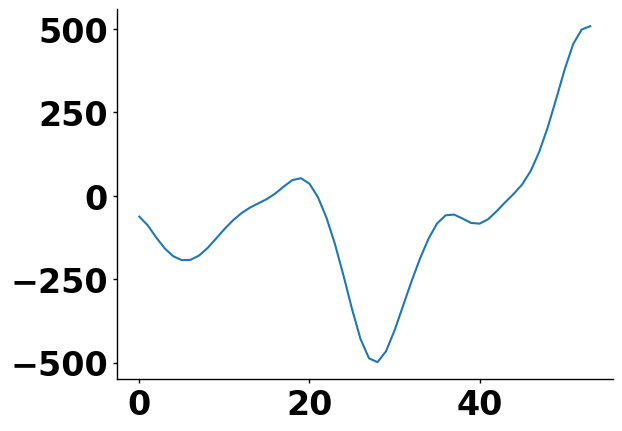

In [136]:
plt.plot(smooth(row.head_angle_velocity[:ob_ind])*60)

In [702]:
long_nostart[(long_nostart.task == 'oadark')].animal.unique()

array(['J704RT', 'J704NN', 'J704LT', 'J704LN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

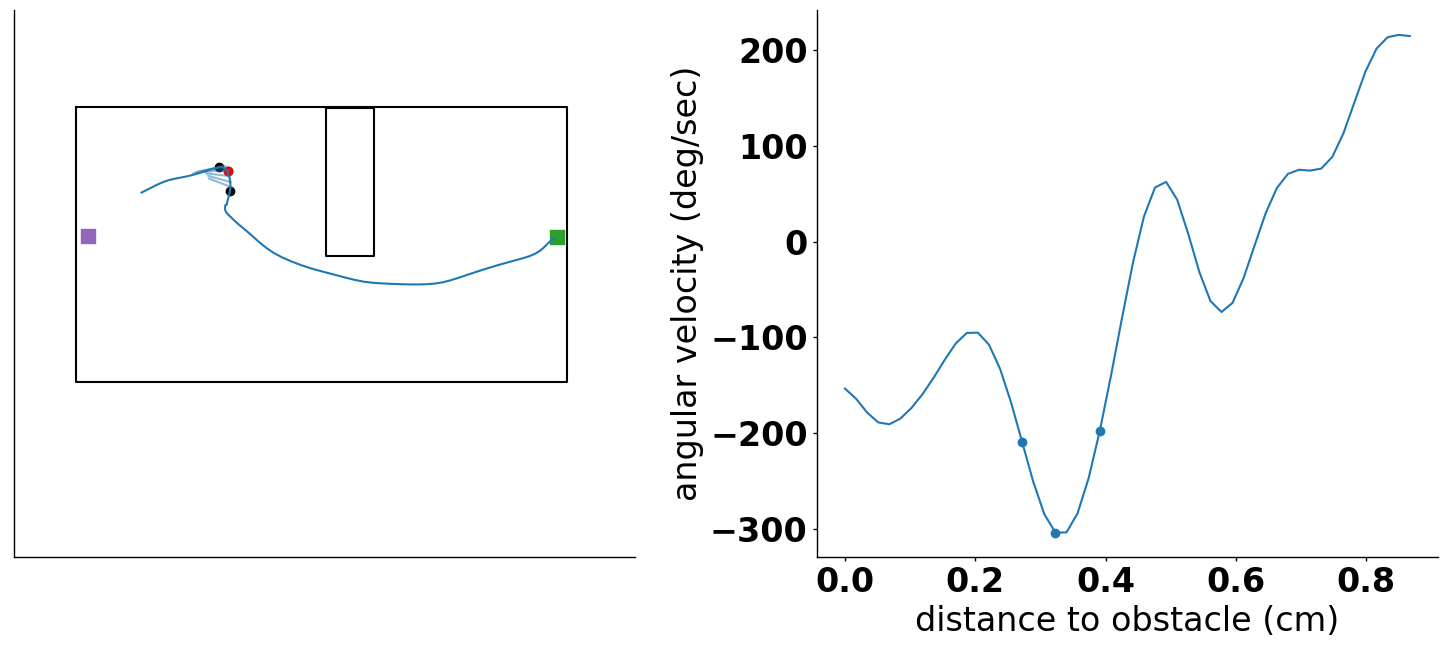

In [771]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample = data.sample(1)
distance_at_head_turn(sample)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(15,7),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks([0,5,10,15,20])
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    #ax[1].invert_yaxis()
    plot_arena(sample,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(sample,ax[0],int(row.obstacle_cluster))



    

   
        
    ob_ind = int(row.obstacle_ind)
    thresh = int(row.indexs_of_head_turn[1])
    peaks = row.indexs_of_head_turn.tolist()
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(smooth(x),smooth(y),color = 'tab:blue')
    ax[0].plot((row.ts_nose_x_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]],row.ts_spine_x_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]]),(row.ts_nose_y_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]],row.ts_spine_y_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]]),color = 'tab:blue',alpha = .5)
    ax[0].scatter(smooth(row.ts_nose_x_cm)[row.indexs_of_head_turn.tolist()],smooth(row.ts_nose_y_cm)[row.indexs_of_head_turn.tolist()],color = 'black')
    ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
    ax[1].plot(np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind])),smooth(row.head_angle_velocity[:ob_ind],sigma = 2)*60)
    ax[1].scatter(np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind]))[row.indexs_of_head_turn.tolist()],(smooth(row.head_angle_velocity[:ob_ind],sigma = 2)*60)[row.indexs_of_head_turn.tolist()])
    #ax[1].scatter(smooth(row.ts_nose_x_cm)[row.indexs_of_head_turn.tolist()],smooth(row.ts_nose_y_cm)[row.indexs_of_head_turn.tolist()],color = 'black')

In [ ]:
"\\goeppert\nlab-nas\Mike\recordings\031624\J701RN\oa\031624_J701RN_control_Rig2_oa_top1.avi"

In [551]:
len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind])

(1.2, 72)

In [550]:
np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind]))

array([0.        , 0.01690141, 0.03380282, 0.05070423, 0.06760563,
       0.08450704, 0.10140845, 0.11830986, 0.13521127, 0.15211268,
       0.16901408, 0.18591549, 0.2028169 , 0.21971831, 0.23661972,
       0.25352113, 0.27042254, 0.28732394, 0.30422535, 0.32112676,
       0.33802817, 0.35492958, 0.37183099, 0.38873239, 0.4056338 ,
       0.42253521, 0.43943662, 0.45633803, 0.47323944, 0.49014085,
       0.50704225, 0.52394366, 0.54084507, 0.55774648, 0.57464789,
       0.5915493 , 0.6084507 , 0.62535211, 0.64225352, 0.65915493,
       0.67605634, 0.69295775, 0.70985915, 0.72676056, 0.74366197,
       0.76056338, 0.77746479, 0.7943662 , 0.81126761, 0.82816901,
       0.84507042, 0.86197183, 0.87887324, 0.89577465, 0.91267606,
       0.92957746, 0.94647887, 0.96338028, 0.98028169, 0.9971831 ,
       1.01408451, 1.03098592, 1.04788732, 1.06478873, 1.08169014,
       1.09859155, 1.11549296, 1.13239437, 1.14929577, 1.16619718,
       1.18309859, 1.2       ])

In [555]:
np.linspace(0,len(row.head_angle_velocity[:ob_ind]))[[18, 30]]

array([26.44897959, 44.08163265])

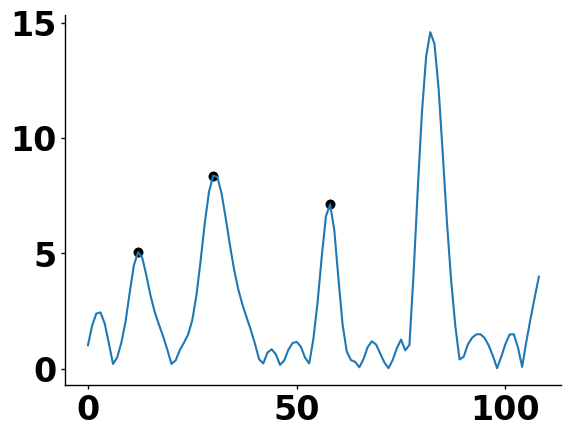

In [651]:
plt.plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]))
plt.scatter([12, 30, 58],[np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[[12, 30, 58]]])
plt.scatter([12, 30, 58],[np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[[12, 30, 58]]],c='black')

In [709]:
prop['peak_heights'].max()

8.504151208794369

In [705]:
peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,20),distance=10)

In [707]:
peaks[prop['peak_heights']]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [649]:
prop

{'peak_heights': array([5.05678714, 8.37281756, 7.12778649]),
 'prominences': array([4.84265012, 8.15985175, 6.95451269]),
 'left_bases': array([ 6,  6, 46], dtype=int64),
 'right_bases': array([20, 72, 72], dtype=int64),
 'widths': array([6.27830422, 8.29707348, 4.73683204]),
 'width_heights': array([2.63546208, 4.29289168, 3.65053014]),
 'left_ips': array([ 9.47240688, 26.72094014, 55.3876798 ]),
 'right_ips': array([15.75071109, 35.01801362, 60.12451184])}

In [569]:
int(np.round(prop['left_ips'][prop['peak_heights'].argmax()]))

27

In [ ]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample = data.sample(1)
distance_at_head_turn(sample)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(15,7),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks([0,5,10,15,20])
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    #ax[1].invert_yaxis()
    plot_arena(sample,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(sample,ax[0],int(row.obstacle_cluster))



    

   
        
    ob_ind = int(row.obstacle_ind)
    thresh = int(row.indexs_of_head_turn[1])
    peaks = row.indexs_of_head_turn.tolist()
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(smooth(x),smooth(y),color = 'tab:blue')
    ax[0].plot((row.ts_nose_x_cm[:row.indexs_of_head_turn.tolist()[-1]][::2],row.ts_spine_x_cm[:row.indexs_of_head_turn.tolist()[-1]][::2]),(row.ts_nose_y_cm[:row.indexs_of_head_turn.tolist()[-1]][::2],row.ts_spine_y_cm[:row.indexs_of_head_turn.tolist()[-1]][::2]),color = 'tab:orange')
    ax[0].scatter(smooth(row.ts_nose_x_cm)[row.indexs_of_head_turn.tolist()],smooth(row.ts_nose_y_cm)[row.indexs_of_head_turn.tolist()],color = 'black')
    ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
    ax[1].plot(np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind])),smooth(row.head_angle_velocity[:ob_ind],sigma = 2)*60)

In [377]:
row.indexs_of_head_turn.tolist()[-1]

33

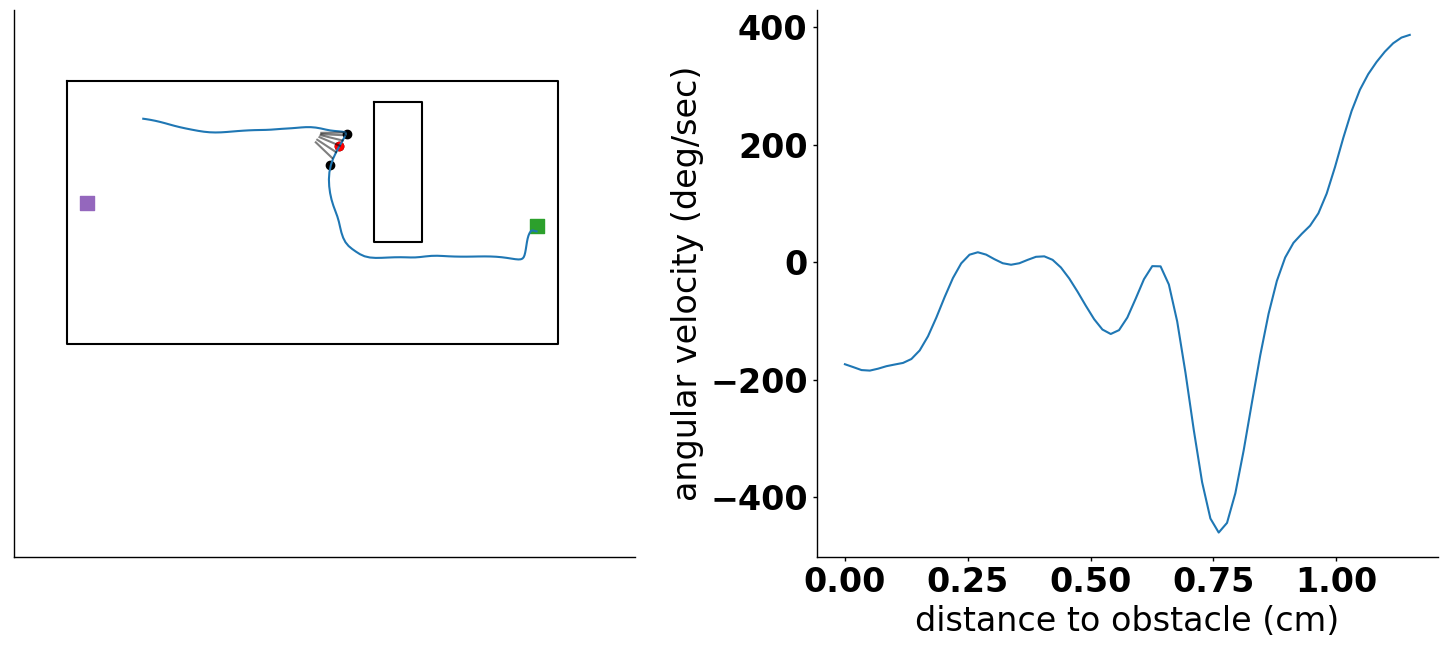

In [594]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oadark')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample = data.sample(1)
distance_at_head_turn(sample)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(15,7),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks([0,5,10,15,20])
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    #ax[1].invert_yaxis()
    plot_arena(sample,ax[0])
    ob_x,ob_y = plot_orginal_obstacle(sample,ax[0],int(row.obstacle_cluster))



    

   
        
    ob_ind = int(row.obstacle_ind)
    thresh = int(row.indexs_of_head_turn[1])
    peaks = row.indexs_of_head_turn.tolist()
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(smooth(x),smooth(y),color = 'tab:blue')
    ax[0].plot((row.ts_nose_x_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]],row.ts_spine_x_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]]),(row.ts_nose_y_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]],row.ts_spine_y_cm[row.indexs_of_head_turn.tolist()[0]:row.indexs_of_head_turn.tolist()[-1]]),color = 'black',alpha = .5)
    ax[0].scatter(smooth(row.ts_nose_x_cm)[row.indexs_of_head_turn.tolist()],smooth(row.ts_nose_y_cm)[row.indexs_of_head_turn.tolist()],color = 'black')
    ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
    ax[1].plot(np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind])),smooth(row.head_angle_velocity[:ob_ind],sigma = 2)*60)

In [451]:
data

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,left_num_turn,left_turns_distances,intial_distance,distance_after_head_turn,distance_before_head_turn,indexs_of_head_turn,distance_at_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,distance_at_head_turn_index
11684,11684,64968.816256,64972.056524,"[64968.829798, 64968.847398, 64968.863283, 649...","[3737, 3738, 3739, 3740, 3741, 3742, 3743, 374...","[99.7690200805664, 99.95110321044922, 100.1369...","[263.3944396972656, 263.34783935546875, 263.12...","[105.5213394165039, 105.59479522705078, 105.43...","[262.14947509765625, 262.2792663574219, 262.10...","[107.3190689086914, 107.4289321899414, 107.326...",...,2.0,"[20.037771758797827, 1.5733307769340357]",22.0,1.262862,1.513418,"[37, 60, 69]","[2, 30, 60]",7.943713,101.260068,NaN
11686,11686,64974.743820,64977.734105,"[64974.749286, 64974.76535, 64974.78222, 64974...","[4092, 4093, 4094, 4095, 4096, 4097, 4098, 409...","[100.6798095703125, 100.27774810791016, 99.864...","[264.3829345703125, 264.21746826171875, 263.56...","[106.44309997558594, 105.49596405029297, 104.7...","[264.0455017089844, 264.8358154296875, 264.900...","[110.2073974609375, 109.18505096435547, 108.76...",...,1.0,[2.275906040342111],22.0,2.097887,10.235256,"[18, 57, 66]","[33, 57]",1.373908,39.581396,NaN
11729,11729,65111.831859,65114.056307,"[65111.845939, 65111.86272, 65111.880166, 6511...","[12315, 12316, 12317, 12318, 12319, 12320, 123...","[99.6734619140625, 99.58108520507812, 99.45096...","[263.77325439453125, 262.85107421875, 261.8324...","[104.93751525878906, 104.5574951171875, 104.26...","[266.1408386230469, 265.83441162109375, 266.20...","[109.75138854980469, 109.43799591064453, 109.7...",...,2.0,"[16.452491285670682, 11.491118290403517]",19.0,4.169794,18.677051,"[0, 12, 23]",[12],2.485376,59.176969,NaN
11731,11731,65116.329702,65118.226304,"[65116.330944, 65116.348313, 65116.364147, 651...","[12584, 12585, 12586, 12587, 12588, 12589, 125...","[100.0877456665039, 99.715087890625, 99.856262...","[264.1125793457031, 264.2441101074219, 264.173...","[107.697998046875, 107.0395278930664, 106.7680...","[259.28900146484375, 259.4296875, 259.41906738...","[107.44329833984375, 106.92704010009766, 106.7...",...,1.0,[16.83160427056933],19.0,7.980197,18.996117,"[0, 3, 15]",[3],21.253592,70.869451,NaN
11733,11733,65120.467072,65122.257100,"[65120.482304, 65120.498969, 65120.516544, 651...","[12833, 12834, 12835, 12836, 12837, 12838, 128...","[98.08152770996094, 98.29341125488281, 98.2131...","[264.10772705078125, 264.5140380859375, 264.47...","[106.09580993652344, 106.43942260742188, 106.4...","[259.1377258300781, 259.345703125, 259.2328491...","[104.99288177490234, 104.98985290527344, 105.1...",...,1.0,[17.139442619021594],19.0,6.995351,19.086351,"[0, 3, 16]","[3, 20]",8.317536,75.106479,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14441,14441,58236.187276,58238.853939,"[58236.201318, 58236.217612, 58236.234444, 582...","[7781, 7782, 7783, 7784, 7785, 7786, 7787, 778...","[87.77838897705078, 87.7995376586914, 87.25485...","[262.18511962890625, 262.17718505859375, 261.2...","[95.75042724609375, 95.21729278564453, 94.8876...","[256.7000427246094, 256.77899169921875, 256.06...","[94.75458526611328, 94.79692840576172, 94.5090...",...,3.0,"[19.29553646730347, 4.348458717747185, 2.64867...",20.0,4.373176,8.752850,"[20, 30, 35]","[2, 30, 41, 51]",12.446547,64.343867,NaN
14457,14457,58292.843865,58295.752435,"[58292.853836, 58292.870553, 58292.888076, 582...","[11179, 11180, 11181, 11182, 11183, 11184, 111...","[88.04179382324219, 87.6558609008789, 87.02273...","[263.0577087402344, 263.07275390625, 262.39840...","[97.41693878173828, 95.97099304199219, 95.0175...","[257.0143737792969, 257.3912353515625, 257.295...","[95.5603256225586, 94.940673828125, 94.3677520...",...,2.0,"[11.756743148388708, 2.6774978614615605]",20.0,5.018140,17.105422,"[5, 39,

In [356]:
row.distance_at_head_turn_indexs

array([3, 37, 56], dtype=object)

In [355]:
row.indexs_of_head_turn

array([22, 37, 48], dtype=object)

In [199]:
row.ts_distance_from_edge[:int(row.obstacle_ind)][71]

7.77341735754635

In [198]:
row.ts_zero_out_angle_to_corner[:int(row.obstacle_ind)][71]

17.12086112004219

In [200]:
peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3,12),distance=10)

In [206]:
prop

{'peak_heights': array([5.57369643, 3.23570415]),
 'prominences': array([5.45840617, 1.39566494]),
 'left_bases': array([25, 71], dtype=int64),
 'right_bases': array([ 71, 102], dtype=int64),
 'widths': array([13.88313299,  4.19287409]),
 'width_heights': array([2.84449334, 2.53787168]),
 'left_ips': array([49.78690564, 95.23711387]),
 'right_ips': array([63.67003863, 99.42998796])}

In [204]:
prop['peak_heights'].argmax()

0

In [207]:
prop['right_bases'][prop['peak_heights'].argmax()]

71

In [201]:
peaks[prop['peak_heights'].argmax()]

53

In [186]:
smooth(row.head_angle_velocity[:ob_ind])*60[

SyntaxError: unexpected EOF while parsing (3865061637.py, line 1)

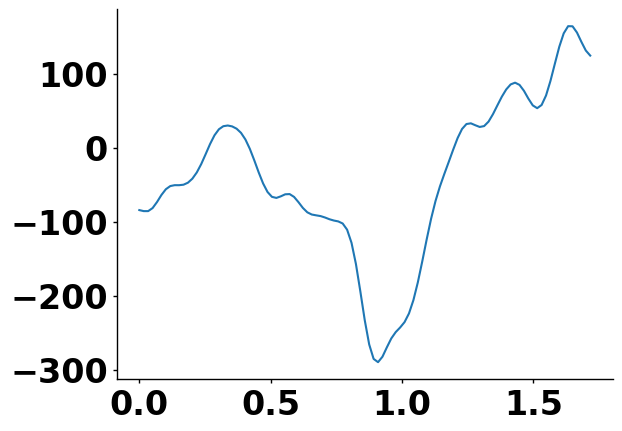

In [257]:
plt.plot(np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind])),smooth(row.head_angle_velocity[:ob_ind],sigma = 2)*60)
#plt.scatter(x = 71,y = (smooth(row.head_angle_velocity[:ob_ind])*60)[71])

In [214]:
len(row.head_angle_velocity[:ob_ind])

103

In [216]:
len(row.head_angle_velocity)

140

In [217]:
140/60

2.3333333333333335

In [220]:
np.linspace(0,len(row.head_angle_velocity[:ob_ind])/60,len(row.head_angle_velocity[:ob_ind]))

array([0.        , 0.01683007, 0.03366013, 0.0504902 , 0.06732026,
       0.08415033, 0.10098039, 0.11781046, 0.13464052, 0.15147059,
       0.16830065, 0.18513072, 0.20196078, 0.21879085, 0.23562092,
       0.25245098, 0.26928105, 0.28611111, 0.30294118, 0.31977124,
       0.33660131, 0.35343137, 0.37026144, 0.3870915 , 0.40392157,
       0.42075163, 0.4375817 , 0.45441176, 0.47124183, 0.4880719 ,
       0.50490196, 0.52173203, 0.53856209, 0.55539216, 0.57222222,
       0.58905229, 0.60588235, 0.62271242, 0.63954248, 0.65637255,
       0.67320261, 0.69003268, 0.70686275, 0.72369281, 0.74052288,
       0.75735294, 0.77418301, 0.79101307, 0.80784314, 0.8246732 ,
       0.84150327, 0.85833333, 0.8751634 , 0.89199346, 0.90882353,
       0.92565359, 0.94248366, 0.95931373, 0.97614379, 0.99297386,
       1.00980392, 1.02663399, 1.04346405, 1.06029412, 1.07712418,
       1.09395425, 1.11078431, 1.12761438, 1.14444444, 1.16127451,
       1.17810458, 1.19493464, 1.21176471, 1.22859477, 1.24542